In [15]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image

In [17]:
train_dir = "/content/drive/MyDrive/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Test"

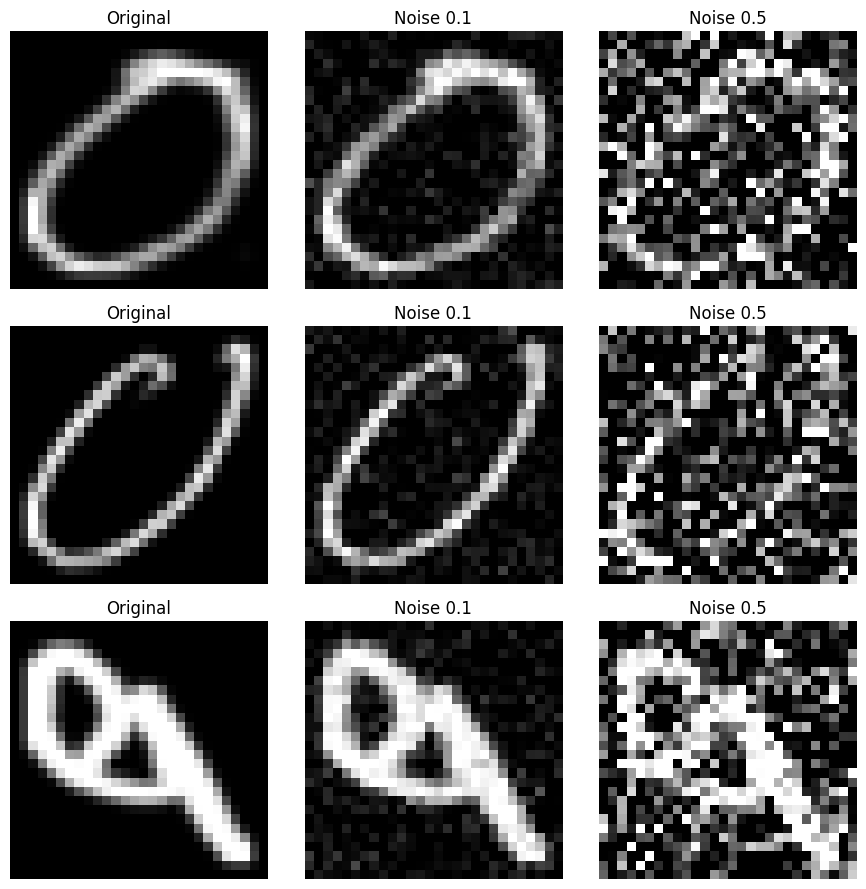

In [29]:
# Define image size
img_height, img_width = 28, 28
from sklearn.utils import shuffle
# Function to load images and labels
def load_images_from_folder(folder):
    images = []
    labels = []
    class_names = sorted(os.listdir(folder))  # Sorted class names (digit_0, digit_1, ...)
    class_map = {name: i for i, name in enumerate(class_names)}  # Map class names to labels

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            img = Image.open(img_path).convert("L")  # Convert to grayscale
            img = img.resize((img_width, img_height))  # Resize to (28,28)
            img = np.array(img) / 255.0  # Normalize pixel values to [0,1]

            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

# Load training and testing datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

x_train, y_train = shuffle(x_train, y_train, random_state=42)
x_test, y_test = shuffle(x_test, y_test, random_state=42)


#Generate noisy versions
noise_factor_low = 0.1
noise_factor_high = 0.5
x_train_noisy_low = x_train + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_train.
shape)
x_train_noisy_high = x_train + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_train
.shape)
x_test_noisy_low = x_test + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_test.
shape)
x_test_noisy_high = x_test + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_test.
shape)
# Clip pixel values to [0, 1]
x_train_noisy_low = np.clip(x_train_noisy_low, 0., 1.)
x_test_noisy_low = np.clip(x_test_noisy_low, 0., 1.)
x_train_noisy_high = np.clip(x_train_noisy_high, 0., 1.)
x_test_noisy_high = np.clip(x_test_noisy_high, 0., 1.)
#Visualize in a 3 x 3 grid
n = 3 # number of images to show
plt.figure(figsize=(9, 9))
for i in range(n):
# Original image
  ax = plt.subplot(n, 3, i * 3 + 1)
  plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
  plt.title("Original")
  plt.axis("off")
# Low noise image
  ax = plt.subplot(n, 3, i * 3 + 2)
  plt.imshow(x_train_noisy_low[i].reshape(28, 28), cmap="gray")
  plt.title("Noise 0.1")
  plt.axis("off")
# High noise image
  ax = plt.subplot(n, 3, i * 3 + 3)
  plt.imshow(x_train_noisy_high[i].reshape(28, 28), cmap="gray")
  plt.title("Noise 0.5")
  plt.axis("off")
plt.tight_layout()
plt.show()


In [30]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [31]:
def build_encoder(input_shape=(28, 28, 1)):

  input_img = Input(shape=input_shape, name="input")
  x = Conv2D(32, (3, 3), activation="relu", padding="same")(input_img)
  x = MaxPooling2D((2, 2), padding="same")(x)
  x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
  encoded = MaxPooling2D((2, 2), padding="same", name="encoded")(x)
  return input_img, encoded

In [32]:
def build_decoder(encoded_input):
  x = Conv2D(64, (3, 3), activation="relu", padding="same")(encoded_input)
  x = UpSampling2D((2, 2))(x)
  x = Conv2D(32, (3, 3), activation="relu", padding="same")(x)
  x = UpSampling2D((2, 2))(x)
  decoded = Conv2D(1, (3, 3), activation="sigmoid", padding="same", name="decoded")(x)
  return decoded

In [33]:
def build_autoencoder():
  input_img, encoded_output = build_encoder()
  decoded_output = build_decoder(encoded_output)
  autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")
  autoencoder.compile(optimizer=Adam(), loss="binary_crossentropy")
  return autoencoder

In [34]:
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_10 (UpSampling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_11 (UpSampling2D) │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:

autoencoder = build_autoencoder()

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("best_model.h5", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True)
]

history = autoencoder.fit(
    x_train_noisy_high, x_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy_high, x_test),
    callbacks=callbacks
)


Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - loss: 0.5630

56/56 ━━━━━━━━━━━━━━━━━━━━ 26s 402ms/step - loss: 0.5609 - val_loss: 0.2654
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - loss: 0.2568

56/56 ━━━━━━━━━━━━━━━━━━━━ 41s 407ms/step - loss: 0.2567 - val_loss: 0.2293
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - loss: 0.2276

56/56 ━━━━━━━━━━━━━━━━━━━━ 41s 411ms/step - loss: 0.2276 - val_loss: 0.2146
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - loss: 0.2183

56/56 ━━━━━━━━━━━━━━━━━━━━ 43s 455ms/step - loss: 0.2183 - val_loss: 0.2077
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - loss: 0.2107

...

56/56 ━━━━━━━━━━━━━━━━━━━━ 41s 417ms/step - loss: 0.1928 - val_loss: 0.1918
Epoch 16/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - loss: 0.1924

56/56 ━━━━━━━━━━━━━━━━━━━━ 43s 454ms/step - loss: 0.1924 - val_loss: 0.1910
Epoch 17/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - loss: 0.1912

56/56 ━━━━━━━━━━━━━━━━━━━━ 41s 457ms/step - loss: 0.1912 - val_loss: 0.1905
Epoch 18/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 39s 419ms/step - loss: 0.1910 - val_loss: 0.1909
Epoch 19/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - loss: 0.1900

56/56 ━━━━━━━━━━━━━━━━━━━━ 41s 427ms/step - loss: 0.1900 - val_loss: 0.1899
Epoch 20/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - loss: 0.1907

56/56 ━━━━━━━━━━━━━━━━━━━━ 42s 453ms/step - loss: 0.1907 - val_loss: 0.1897


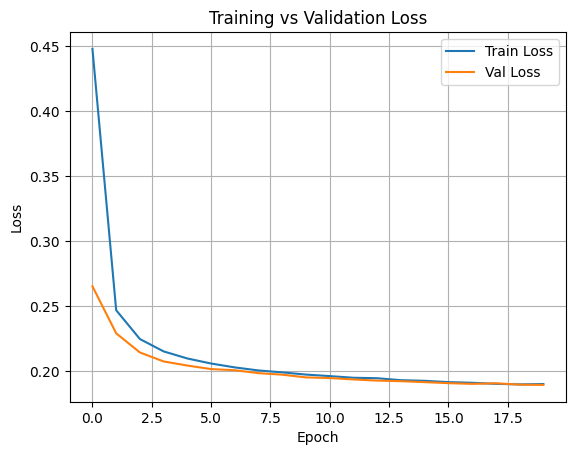

In [36]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.grid(True)
plt.show()


In [37]:
from tensorflow.keras.models import load_model
autoencoder.save("Sulok_autoencoder.h5")
loaded_autoencoder = load_model("Sulok_autoencoder.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step


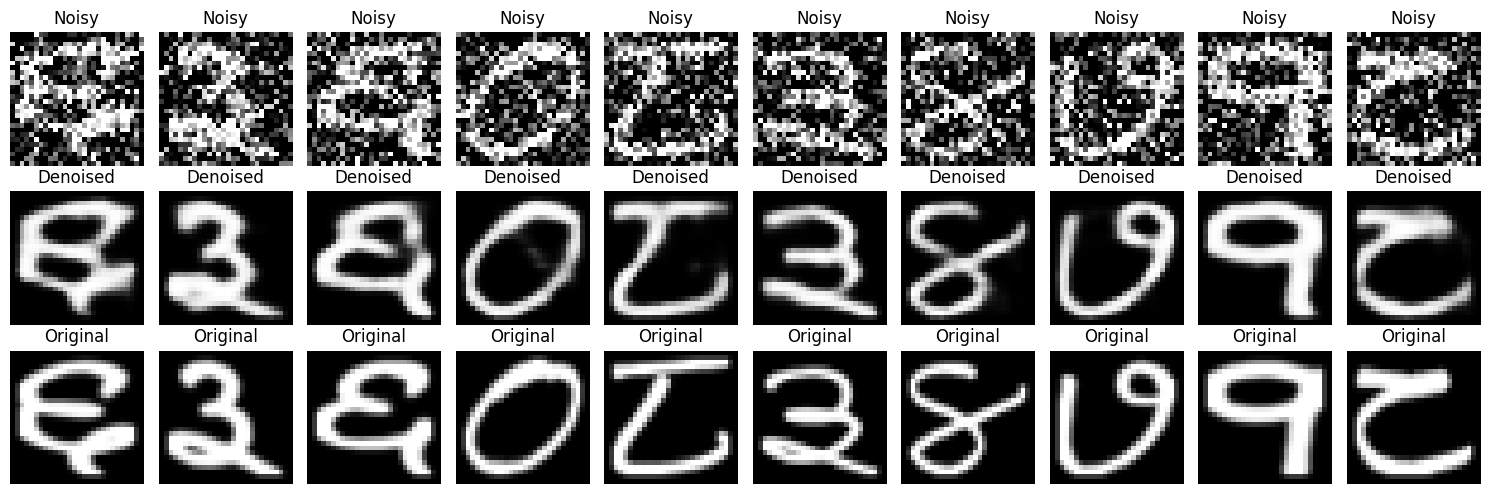

In [39]:
def show_denoising_results(model, x_noisy, x_clean, n=10):

    decoded_imgs = model.predict(x_noisy[:n])

    plt.figure(figsize=(15, 5))
    for i in range(n):
        ax = plt.subplot(3, n, i + 1)
        plt.imshow(x_noisy[i].reshape(28, 28), cmap='gray')
        plt.title("Noisy")
        plt.axis('off')

        ax = plt.subplot(3, n, i + 1 + n)
        plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
        plt.title("Denoised")
        plt.axis('off')

        ax = plt.subplot(3, n, i + 1 + 2*n)
        plt.imshow(x_clean[i].reshape(28, 28), cmap='gray')
        plt.title("Original")
        plt.axis('off')

    plt.tight_layout()
    plt.show()
show_denoising_results(loaded_autoencoder, x_test_noisy_high, x_test, n=10)

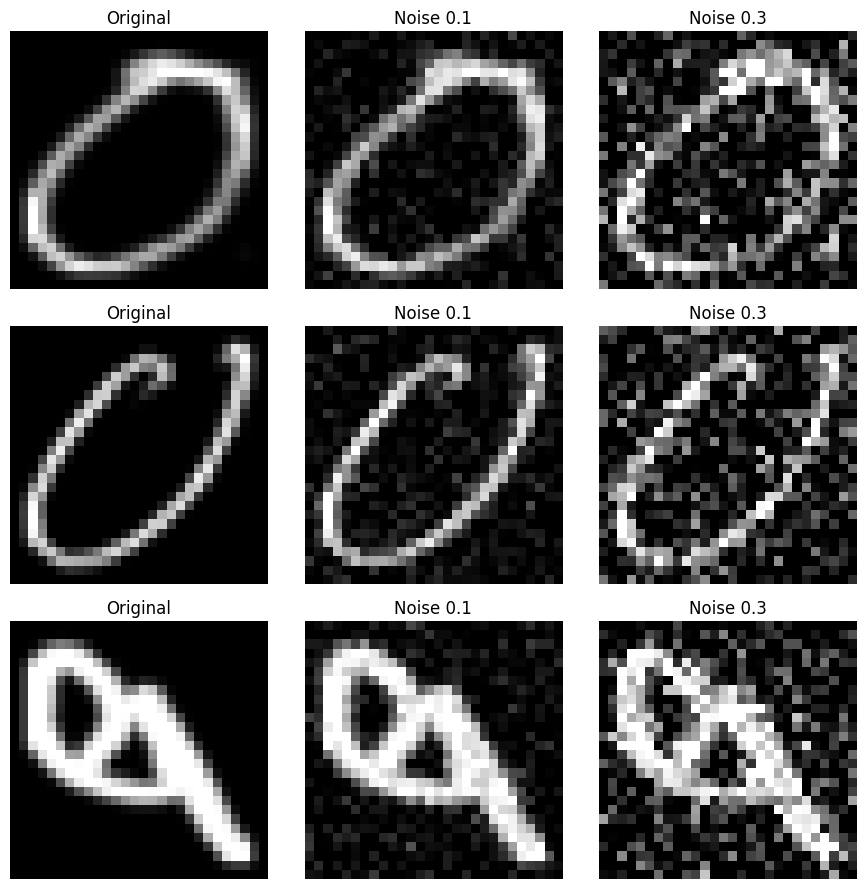

In [41]:
noise_factor_low = 0.1
noise_factor_high = 0.3
x_train_noisy_low = x_train + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_train.
shape)
x_train_noisy_high = x_train + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_train
.shape)
x_test_noisy_low = x_test + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_test.
shape)
x_test_noisy_high = x_test + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_test.
shape)
# Clip pixel values to [0, 1]
x_train_noisy_low = np.clip(x_train_noisy_low, 0., 1.)
x_test_noisy_low = np.clip(x_test_noisy_low, 0., 1.)
x_train_noisy_high = np.clip(x_train_noisy_high, 0., 1.)
x_test_noisy_high = np.clip(x_test_noisy_high, 0., 1.)

plt.figure(figsize=(9, 9))
for i in range(n):
# Original image
  ax = plt.subplot(n, 3, i * 3 + 1)
  plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
  plt.title("Original")
  plt.axis("off")
# Low noise image
  ax = plt.subplot(n, 3, i * 3 + 2)
  plt.imshow(x_train_noisy_low[i].reshape(28, 28), cmap="gray")
  plt.title("Noise 0.1")
  plt.axis("off")
# High noise image
  ax = plt.subplot(n, 3, i * 3 + 3)
  plt.imshow(x_train_noisy_high[i].reshape(28, 28), cmap="gray")
  plt.title("Noise 0.3")
  plt.axis("off")
plt.tight_layout()
plt.show()


In [47]:
def build_encoder(input_shape=(28, 28, 1)):

  input_img = Input(shape=input_shape, name="input")
  x = Conv2D(32, (3, 3), activation="relu", padding="same")(input_img)
  x = MaxPooling2D((2, 2), padding="same")(x)
  x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
  x = MaxPooling2D((2, 2), padding="same")(x)
  x = Conv2D(128, (3, 3), activation="relu", padding="same")(x)
  encoded = MaxPooling2D((2, 2), padding="same", name="encoded")(x)
  return input_img, encoded

In [52]:
from tensorflow.keras.layers import Cropping2D
def build_decoder(encoded_input):
  x = Conv2D(128, (3, 3), activation="relu", padding="same")(encoded_input)
  x = UpSampling2D((2, 2))(x)
  x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
  x = UpSampling2D((2, 2))(x)
  x = Conv2D(32, (3, 3), activation="relu", padding="same")(x)
  x = UpSampling2D((2, 2))(x)
  decoded = Conv2D(1, (3, 3), activation="sigmoid", padding="same", name="decoded")(x)
  decoded = Cropping2D(((2,2), (2,2)))(decoded)
  return decoded

In [53]:
def build_autoencoder():
  input_img, encoded_output = build_encoder()
  decoded_output = build_decoder(encoded_output)
  autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")
  autoencoder.compile(optimizer=Adam(), loss="binary_crossentropy")
  return autoencoder

In [54]:
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_23 (UpSampling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_24 (UpSampling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_25 (UpSampling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 32, 32, 1)      │           289 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cropping2d (Cropping2D)         │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332,801 (1.27 MB)

 Trainable params: 332,801 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:

autoencoder = build_autoencoder()

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("best_model.h5", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True)
]

history = autoencoder.fit(
    x_train_noisy_high, x_train,
    epochs=30,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy_high, x_test),
    callbacks=callbacks
)

Epoch 1/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 647ms/step - loss: 0.5368

56/56 ━━━━━━━━━━━━━━━━━━━━ 46s 756ms/step - loss: 0.5351 - val_loss: 0.3320
Epoch 2/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 646ms/step - loss: 0.2926

56/56 ━━━━━━━━━━━━━━━━━━━━ 80s 729ms/step - loss: 0.2923 - val_loss: 0.2668
Epoch 3/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 637ms/step - loss: 0.2495

56/56 ━━━━━━━━━━━━━━━━━━━━ 39s 698ms/step - loss: 0.2494 - val_loss: 0.2422
Epoch 4/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - loss: 0.2260

56/56 ━━━━━━━━━━━━━━━━━━━━ 40s 708ms/step - loss: 0.2260 - val_loss: 0.2271
Epoch 5/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 662ms/step - loss: 0.2114

...

56/56 ━━━━━━━━━━━━━━━━━━━━ 41s 719ms/step - loss: 0.1706 - val_loss: 0.1783
Epoch 23/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 40s 718ms/step - loss: 0.1701 - val_loss: 0.1790
Epoch 24/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 649ms/step - loss: 0.1690

56/56 ━━━━━━━━━━━━━━━━━━━━ 40s 706ms/step - loss: 0.1690 - val_loss: 0.1770
Epoch 25/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 41s 726ms/step - loss: 0.1685 - val_loss: 0.1814
Epoch 26/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 39s 691ms/step - loss: 0.1695 - val_loss: 0.1773
Epoch 27/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 634ms/step - loss: 0.1682

56/56 ━━━━━━━━━━━━━━━━━━━━ 41s 693ms/step - loss: 0.1682 - val_loss: 0.1764
Epoch 28/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 645ms/step - loss: 0.1681

56/56 ━━━━━━━━━━━━━━━━━━━━ 42s 702ms/step - loss: 0.1681 - val_loss: 0.1754
Epoch 29/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 44s 757ms/step - loss: 0.1667 - val_loss: 0.1763
Epoch 30/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 689ms/step - loss: 0.1669

56/56 ━━━━━━━━━━━━━━━━━━━━ 81s 747ms/step - loss: 0.1669 - val_loss: 0.1748


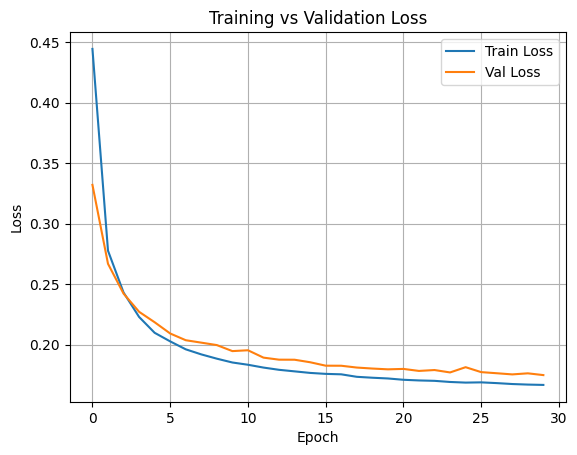

In [56]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.grid(True)
plt.show()


In [57]:
from tensorflow.keras.models import load_model
autoencoder.save("Sulok_autoencoder1.h5")
loaded_autoencoder = load_model("Sulok_autoencoder.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step


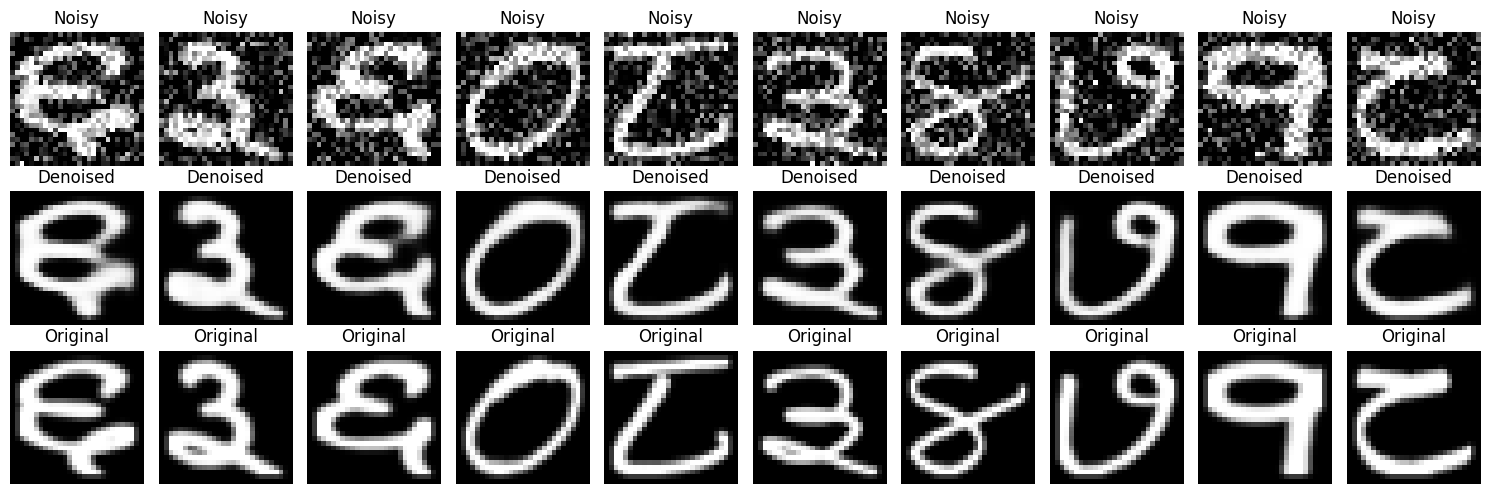

In [58]:
def show_denoising_results(model, x_noisy, x_clean, n=10):

    decoded_imgs = model.predict(x_noisy[:n])

    plt.figure(figsize=(15, 5))
    for i in range(n):
        ax = plt.subplot(3, n, i + 1)
        plt.imshow(x_noisy[i].reshape(28, 28), cmap='gray')
        plt.title("Noisy")
        plt.axis('off')

        ax = plt.subplot(3, n, i + 1 + n)
        plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
        plt.title("Denoised")
        plt.axis('off')

        ax = plt.subplot(3, n, i + 1 + 2*n)
        plt.imshow(x_clean[i].reshape(28, 28), cmap='gray')
        plt.title("Original")
        plt.axis('off')

    plt.tight_layout()
    plt.show()
show_denoising_results(loaded_autoencoder, x_test_noisy_high, x_test, n=10)